In [2]:
import pandas as pd

df = pd.read_csv('data.csv') 

print(f"Liczba prób w zbiorze: {len(df)}")

df.info()


Liczba prób w zbiorze: 569
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14 

In [4]:
print(f"Liczba kolumn: {df.shape[1]}")


Liczba kolumn: 33


In [9]:
df['diagnosis'].value_counts()



diagnosis
B    357
M    212
Name: count, dtype: int64

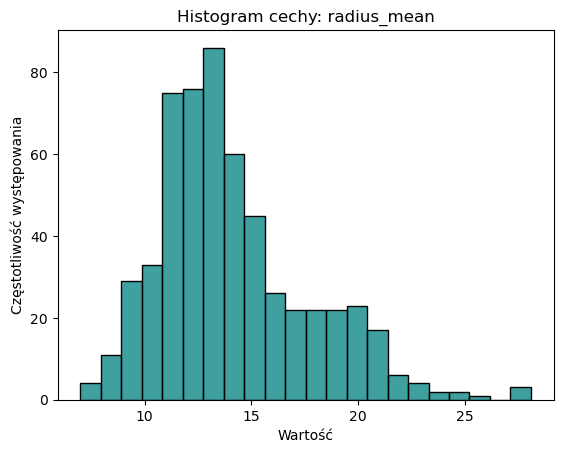

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Wczytanie danych (na wypadek restartu kernela)
df = pd.read_csv('data.csv')

# 2. Tworzenie prostego histogramu dla JEDNEJ cechy
# Możesz zmienić 'radius_mean' na dowolną inną kolumnę z Twojej tabeli
sns.histplot(df['radius_mean'], color='teal', edgecolor='black')

# 3. Dodanie tytułu i etykiet
plt.title("Histogram cechy: radius_mean")
plt.xlabel("Wartość")
plt.ylabel("Częstotliwość występowania")

# 4. Wyświetlenie
plt.show()


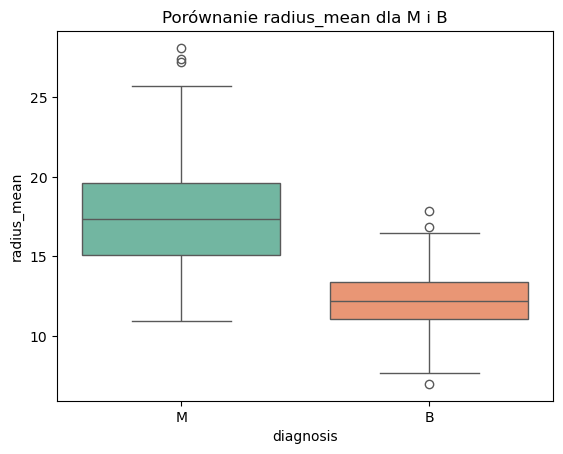

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv')

sns.boxplot(data=df, x='diagnosis', y='radius_mean', hue='diagnosis', palette='Set2', legend=False)



plt.title("Porównanie radius_mean dla M i B")
plt.show()


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# 1. Przygotowanie X i y
# Usuwamy kolumnę celu oraz techniczne/puste kolumny, jeśli istnieją
drop_cols = ['diagnosis', 'id', 'Unnamed: 32']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['diagnosis']

# 2. Podział na zbiór treningowy i testowy ze stratify
# stratify=y gwarantuje, że proporcja klas M/B będzie taka sama w obu zbiorach
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Liczenie Accuracy Baseline (zawsze najczęstsza klasa)
# Używamy DummyClassifier z strategią 'most_frequent'
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

# Predykcja i wynik
y_pred = baseline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy (najczęstsza klasa): {accuracy:.4f}")


Baseline Accuracy (najczęstsza klasa): 0.6316
